# 🐍🔍 Detection & Segmentation Colab Notebook
This notebook demonstrates **YOLOv8** for object detection & segmentation and **U‑Net** for semantic segmentation.

Run each section on a GPU runtime (e.g., Colab **`Runtime → Change runtime type → GPU`**).


Change the Google Colab working directory to a specific folder in Google Drive so that the training results and optimized weights can be saved safely and are not lost if the Colab session disconnects.

In [ ]:
"""import os, pathlib

target = pathlib.Path("/content/drive/MyDrive/NCAI/KPITB/Lectures/KPITB Swat AI Lectures/W7/dataset/kpitboard")
os.chdir(target)
print("Now in:", pathlib.Path.cwd())"""

Now in: /content/drive/MyDrive/NCAI/KPITB/Lectures/KPITB Swat AI Lectures/W7/dataset/kpitboard


In [ ]:
#pwd

'/content/drive/MyDrive/NCAI/KPITB/Lectures/KPITB Swat AI Lectures/W7/dataset/kpitboard'

In [3]:
#!pip install ultralytics segmentation-models-pytorch torchmetrics albumentations

In [1]:
import torch, warnings, os, sys
from ultralytics import YOLO
print('Torch CUDA available:', torch.cuda.is_available())

Torch CUDA available: True


## 1️⃣ YOLOv8 – Detection on **coco128**

to train the YOLOv8s model on your license plate dataset for 20 epochs. Once this finishes, we can proceed to evaluation and inference.

In [5]:
"""
# you want to work on google colab you may need the following code

#from google.colab import files
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# 1. Upload file from PC
uploaded = files.upload()

if uploaded:
    # Get the filename of the uploaded image
    img_path = list(uploaded.keys())[0]

    # 2. Load the best weights from your recent training
    model = YOLO('runs/detect/train/weights/best.pt')

    # 3. Run inference
    results = model.predict(source=img_path, save=True, conf=0.25)

    # 4. Visualize the result
    # Resulting image is stored in results[0].plot()
    res_plotted = results[0].plot()

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Prediction on: {img_path}')
    plt.show()
    """

"\n# you want to work on google colab you may need the following code\n\n#from google.colab import files\nimport matplotlib.pyplot as plt\nimport cv2\nfrom ultralytics import YOLO\n\n# 1. Upload file from PC\nuploaded = files.upload()\n\nif uploaded:\n    # Get the filename of the uploaded image\n    img_path = list(uploaded.keys())[0]\n\n    # 2. Load the best weights from your recent training\n    model = YOLO('runs/detect/train/weights/best.pt')\n\n    # 3. Run inference\n    results = model.predict(source=img_path, save=True, conf=0.25)\n\n    # 4. Visualize the result\n    # Resulting image is stored in results[0].plot()\n    res_plotted = results[0].plot()\n\n    plt.figure(figsize=(10, 10))\n    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))\n    plt.axis('off')\n    plt.title(f'Prediction on: {img_path}')\n    plt.show()\n    "

In [2]:
from ultralytics import YOLO

# Load a pretrained YOLOv8s model
model = YOLO('yolov8s.pt')

# Train the model
results = model.train(
    data='C:\\Users\\Saif Ullah\\KPITB-Course\\week 7\\Number_Plate_dataset.yolov8\\data.yaml',
    epochs=20,
    imgsz=640
)

Ultralytics 8.4.21  Python-3.12.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1050 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=

In [3]:
# Inference example (single image) — outputs saved to runs/detect/predict
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source='https://ultralytics.com/images/bus.jpg' save=True

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\MiniForge\envs\kpitb_env\Scripts\yolo.exe\__main__.py", line 5, in <module>
  File "c:\MiniForge\envs\kpitb_env\Lib\site-packages\ultralytics\cfg\__init__.py", line 956, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "c:\MiniForge\envs\kpitb_env\Lib\site-packages\ultralytics\models\yolo\model.py", line 76, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "c:\MiniForge\envs\kpitb_env\Lib\site-packages\ultralytics\engine\model.py", line 144, in __init__
    self._load(model, task=task)
  File "c:\MiniForge\envs\kpitb_env\Lib\site-packages\ultralytics\engine\model.py", line 283, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\MiniForge\envs\kpitb_env\Lib\site-packages\ultralytics\nn\tasks.

That will prompt you to upload an image from your computer. Once you select a file, the code will automatically run the YOLOv8 model on it and display the detection results right here in the notebook.


image 1/1 C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test.jpg: 640x480 1 license, 42.2ms
Speed: 2.1ms preprocess, 42.2ms inference, 11.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\Saif Ullah\KPITB-Course\week 7\runs\detect\predict


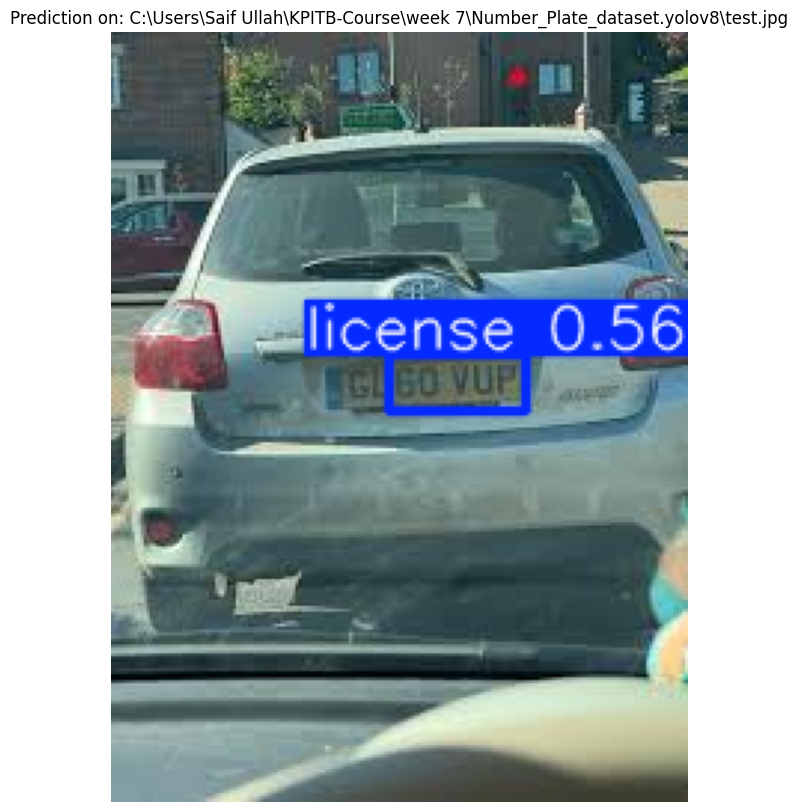

In [3]:
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# 1. Set the path to your image directly
img_path = r"C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test.jpg"

# 2. Load the best weights from your recent training
model = YOLO('runs/detect/train5/weights/best.pt')

# 3. Run inference
results = model.predict(source=img_path, save=True, conf=0.25)

# 4. Visualize the result
res_plotted = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Prediction on: {img_path}')
plt.show()

that will prompt you to upload a video file. Once uploaded, the code will run the YOLOv8 model on the video and save the resulting video with detections to your current working directory. Note that processing a video may take some time depending on its length.

In [6]:
"""
For google colab use the following code.

from google.colab import files
from ultralytics import YOLO
import os

# 1. Upload video from PC
uploaded = files.upload()

if uploaded:
    # Get the filename of the uploaded video
    video_path = list(uploaded.keys())[0]

    # 2. Load the best weights
    model = YOLO('runs/detect/train/weights/best.pt')

    # 3. Run inference on the video and save result
    # The results will be saved as a .avi or .mp4 in the runs/detect/predict folder
    results = model.predict(source=video_path, save=True, conf=0.25)

    print(f'\nProcessing complete. The annotated video is saved in the latest "runs/detect/predict" directory.')
    """

'\nFor google colab use the following code.\n\nfrom google.colab import files\nfrom ultralytics import YOLO\nimport os\n\n# 1. Upload video from PC\nuploaded = files.upload()\n\nif uploaded:\n    # Get the filename of the uploaded video\n    video_path = list(uploaded.keys())[0]\n\n    # 2. Load the best weights\n    model = YOLO(\'runs/detect/train/weights/best.pt\')\n\n    # 3. Run inference on the video and save result\n    # The results will be saved as a .avi or .mp4 in the runs/detect/predict folder\n    results = model.predict(source=video_path, save=True, conf=0.25)\n\n    print(f\'\nProcessing complete. The annotated video is saved in the latest "runs/detect/predict" directory.\')\n    '

In [ ]:
# if you want to use this model on the video, you csn use this code
from ultralytics import YOLO
import os

# 1. Upload video from PC
video_path = r"C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test.jpg"


# 2. Load the best weights
model = YOLO('runs/detect/train5/weights/best.pt')

# 3. Run inference on the video and save result
# The results will be saved as a .avi or .mp4 in the runs/detect/predict folder
results = model.predict(source=video_path, save=True, conf=0.25)

print(f'\nProcessing complete. The annotated video is saved in the latest "runs/detect/predict" directory.')

Saving Test Video.mp4 to Test Video.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2531) /content/drive/MyDrive/NCAI/KPITB/Lectures/KPITB Swat AI Lectures/W7/dataset/kpitboard/Test Video.mp4: 384x640 1 license, 47.0ms
video 1/1 (frame 2/2531) /content/drive/MyDrive/NCAI/KPITB/Lectures/KPITB Swat AI Lectures/W7/dataset/kpitboard/Test Video.mp4: 384x640 1 license, 10.6ms
video 1/1 (frame 3/2531) /content/drive/MyDrive/NCAI/KPITB/Lectures/KPITB Swat AI Lectures/W7/dataset/kpitboar

The training is complete, I will run the evaluation on the 'test' split defined in your YAML file. I'll also run a prediction command on the test source so that the labeled images are saved to your Google Drive folder.

In [7]:
# Validate the model on the test set
metrics = model.val(split='test')
print(f"Mean Precision: {metrics.results_dict['metrics/precision(B)']}")
print(f"Mean Recall: {metrics.results_dict['metrics/recall(B)']}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']}")

Ultralytics 8.4.21  Python-3.12.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1050 Ti with Max-Q Design, 4096MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 92.055.5 MB/s, size: 35.8 KB)
val: Scanning C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test\labels... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 750.0it/s 0.0s
val: New cache created: C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.0s/it 4.0s
                   all          3          3       0.97          1      0.995      0.448
Speed: 2.2ms preprocess, 31.0ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to C:\Users\Saif Ullah\KPITB-Course\week 7\runs\detect\val
Mean Precision: 0.9700098197184375
Mean Recall: 1.0
mAP50: 0.995


Images from your test set have been processed and the results (with bounding boxes) are saved in your Google Drive directory

In [10]:
# Run inference on the test set images and save results
!yolo task=detect mode=predict model=runs/detect/train5/weights/best.pt source="C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test\images" save=True

Ultralytics 8.4.21  Python-3.12.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1050 Ti with Max-Q Design, 4096MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/3 C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test\images\Cars22_png.rf.b0e9dd2ec172f3755ac99cd227433c3f.jpg: 640x640 2 licenses, 28.3ms
image 2/3 C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test\images\Cars2_png.rf.9561497b7eb523b456bb9ca3ec0b96f8.jpg: 640x640 2 licenses, 28.2ms
image 3/3 C:\Users\Saif Ullah\KPITB-Course\week 7\Number_Plate_dataset.yolov8\test\images\Cars7_png.rf.74ee301fe4ab43e43f3b868337e6183b.jpg: 640x640 2 licenses, 28.3ms
Speed: 8.4ms preprocess, 28.3ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Saif Ullah\KPITB-Course\week 7\runs\detect\predict2
 Learn more at https://docs.ultralytics.com/modes/predict
